In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # ganti '-1' kalau OOM

import re
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PATHS — sesuaikan dengan struktur folder kamu
# ============================================================
TRAIN_CSV    = 'youtube_enriched_cluster.csv'
TEST_CSV     = 'new_videos_labeled.csv'
MODEL_PATH   = 'final_multimodal_model.h5'
THUMB_DIR    = 'thumbnails_new'
OUTPUT_CSV   = 'test_results.csv'
# ============================================================

MAX_NUM_WORDS  = 10000
MAX_SEQ_LENGTH = 15
IMG_SIZE       = (224, 224)

# Mapping cluster → performa (sama seperti yang kamu pakai)
cluster_to_label = {2: 'tinggi', 1: 'sedang', 0: 'rendah'}
CLASS_ORDER = ['rendah', 'sedang', 'tinggi']  # urutan LabelEncoder (alphabetical)

In [2]:
# ============================================================
# STEP 1 — Rebuild tokenizer dari training data
# ============================================================
print("📂 Rebuilding tokenizer from training data...")
train_df = pd.read_csv(TRAIN_CSV)

stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words and len(w) > 1])
    return text

train_df['clean_title'] = train_df['Title'].apply(clean_text)
train_df = train_df[train_df['clean_title'].str.len() > 0].copy()

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_title'])
print(f"✅ Tokenizer rebuilt — vocab size: {len(tokenizer.word_index)}")

📂 Rebuilding tokenizer from training data...
✅ Tokenizer rebuilt — vocab size: 2820


In [3]:
# ============================================================
# STEP 2 — Load & preprocess test data
# ============================================================
print("\n📂 Loading test data...")
test_df = pd.read_csv(TEST_CSV)

# Apply cluster → performa mapping
test_df['performa'] = test_df['cluster_label'].map(cluster_to_label)
test_df = test_df[test_df['performa'].notna()].copy()

# Rename Title kolom kalau perlu
if 'title' in test_df.columns and 'Title' not in test_df.columns:
    test_df.rename(columns={'title': 'Title'}, inplace=True)

# Clean title
test_df['clean_title'] = test_df['Title'].apply(clean_text)
test_df = test_df[test_df['clean_title'].str.len() > 0].copy()

# Pastikan thumbnail ada
def thumb_exists(row):
    vid_id = os.path.splitext(os.path.basename(str(row.get('thumbnail_path', ''))))[0]
    path = os.path.join(THUMB_DIR, f'{vid_id}.jpg')
    if not os.path.exists(path):
        path = os.path.join(THUMB_DIR, f'_{vid_id}.jpg')
    return os.path.exists(path)

test_df['thumb_ok'] = test_df.apply(thumb_exists, axis=1)
test_df = test_df[test_df['thumb_ok']].reset_index(drop=True)
print(f"✅ Test samples after filtering: {len(test_df)}")
print(f"   Distribusi:\n{test_df['performa'].value_counts()}")

# Encode label (harus sama urutan dengan training)
le = LabelEncoder()
le.fit(CLASS_ORDER)
test_df['performa_encoded'] = le.transform(test_df['performa'])
num_classes = len(CLASS_ORDER)

# Tokenize title
test_sequences = tokenizer.texts_to_sequences(test_df['clean_title'])
test_padded    = pad_sequences(test_sequences, maxlen=MAX_SEQ_LENGTH, padding='post')


# ============================================================
# STEP 3 — Load model
# ============================================================
print(f"\n🔧 Loading model from '{MODEL_PATH}'...")
model = load_model(MODEL_PATH)
print("✅ Model loaded")


📂 Loading test data...
✅ Test samples after filtering: 1604
   Distribusi:
performa
rendah    948
sedang    531
tinggi    125
Name: count, dtype: int64

🔧 Loading model from 'final_multimodal_model.h5'...
✅ Model loaded


In [4]:

# ============================================================
# STEP 4 — Preprocess images & predict
# ============================================================
print("\n🖼️  Loading and preprocessing thumbnails...")
images = []
valid_idx = []

for i, row in test_df.iterrows():
    vid_id = os.path.splitext(os.path.basename(str(row.get('thumbnail_path', ''))))[0]
    path   = os.path.join(THUMB_DIR, f'{vid_id}.jpg')
    if not os.path.exists(path):
        path = os.path.join(THUMB_DIR, f'_{vid_id}.jpg')
    img = load_img(path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0  # rescale sama seperti val_augmentor
    images.append(img_array)
    valid_idx.append(i)

images_array = np.array(images)
text_array   = test_padded[valid_idx]
true_labels  = test_df.loc[valid_idx, 'performa_encoded'].values
test_df_valid = test_df.loc[valid_idx].reset_index(drop=True)

print(f"✅ Images loaded: {len(images_array)}")

print("\n🔮 Predicting...")
predictions = model.predict(
    {'image_input': images_array, 'text_input': text_array},
    batch_size=32,
    verbose=1
)

pred_classes = np.argmax(predictions, axis=1)
pred_labels  = le.inverse_transform(pred_classes)
true_labels_str = le.inverse_transform(true_labels)


🖼️  Loading and preprocessing thumbnails...
✅ Images loaded: 1604

🔮 Predicting...
51/51 [==============================] - 5s 14ms/step



📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      rendah       0.95      0.91      0.93       948
      sedang       0.90      0.93      0.91       531
      tinggi       0.60      0.73      0.66       125

    accuracy                           0.90      1604
   macro avg       0.82      0.86      0.83      1604
weighted avg       0.91      0.90      0.91      1604



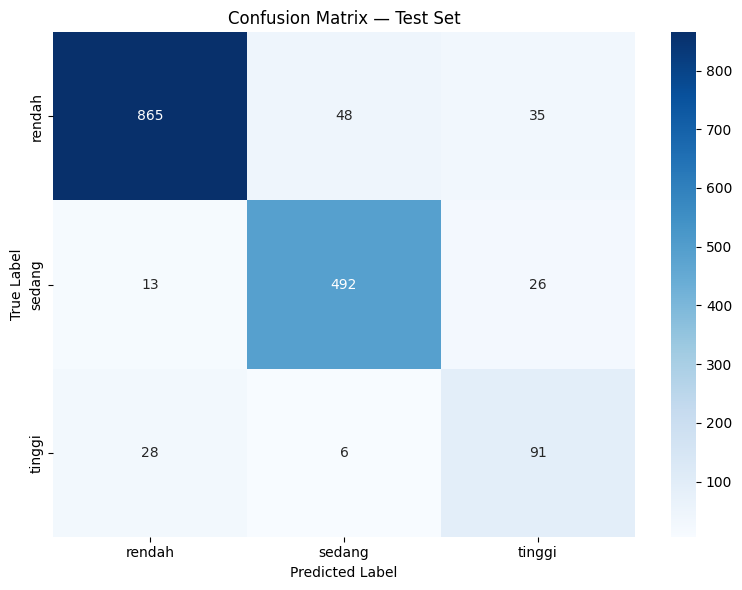

✅ Confusion matrix saved → 'confusion_matrix.png'

🎯 Overall Accuracy: 0.9027 (90.27%)


In [5]:
# ============================================================
# STEP 5 — Evaluasi
# ============================================================
print("\n" + "="*50)
print("📊 CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_labels_str, pred_labels, target_names=CLASS_ORDER))

# Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels, labels=CLASS_ORDER)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved → 'confusion_matrix.png'")

# Overall accuracy
accuracy = np.mean(pred_classes == true_labels)
print(f"\n🎯 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [6]:
# ============================================================
# STEP 6 — Simpan hasil prediksi
# ============================================================
test_df_valid['predicted_performa'] = pred_labels
test_df_valid['true_performa']      = true_labels_str
test_df_valid['correct']            = test_df_valid['predicted_performa'] == test_df_valid['true_performa']
test_df_valid.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Hasil prediksi disimpan → '{OUTPUT_CSV}'")


✅ Hasil prediksi disimpan → 'test_results.csv'


In [9]:
test = pd.read_csv('test_results.csv')

test.head(20)

,video_id,channel,Category,Title,published_at,view_count,like_count,comment_count,subscriber_count,thumbnail_path,...,log_comment_count,log_subscriber_count,cluster_label,performa,clean_title,thumb_ok,performa_encoded,predicted_performa,true_performa,correct
0,fUO3j_XJYOU,Deddy Corbuzier,People & Blogs,POV PUNYA KAKAK KELAKUANNYA ANEH-ANEH BANGET.....,2026-06-02 05:30:08+00:00,73961,1657,28,2540000,thumbnails_new/fUO3j_XJYOU.jpg,...,3.367296,14.747675,0,rendah,pov kakak kelakuannya anehaneh banget shorts,True,0,rendah,rendah,True
1,YUtTPbrkgfY,Deddy Corbuzier,People & Blogs,"""NEVER BREAK THE PASTA. EVER.""",2026-05-24 07:00:13+00:00,12591,249,8,2540000,thumbnails_new/YUtTPbrkgfY.jpg,...,2.197225,14.747675,0,rendah,never break the pasta ever,True,0,rendah,rendah,True
2,ZCMRbxAhPRg,Deddy Corbuzier,People & Blogs,"""What Indonesians did to Italian food is a cri...",2026-05-24 03:30:18+00:00,25480,620,54,2540000,thumbnails_new/ZCMRbxAhPRg.jpg,...,4.007333,14.747675,1,sedang,what indonesians did to italian food is crime ...,True,1,sedang,sedang,True
3,iYy7wB4d8K0,Deddy Corbuzier,People & Blogs,"COOKIES GUILT FREE, zero sugar, low carbs, glu...",2026-05-19 06:30:12+00:00,826566,27993,351,2540000,thumbnails_new/iYy7wB4d8K0.jpg,...,5.863631,14.747675,0,rendah,cookies guilt free zero sugar low carbs gluten...,True,0,rendah,rendah,True
4,k9UfBBsIawI,Deddy Corbuzier,People & Blogs,"DATING YOUR ""SIBLING""?! FOR REAL??",2026-05-17 07:00:38+00:00,23916,495,3,2540000,thumbnails_new/k9UfBBsIawI.jpg,...,1.386294,14.747675,0,rendah,dating your sibling for real,True,0,rendah,rendah,True
5,X6mvUV_dBRs,Deddy Corbuzier,People & Blogs,THE SECRETS OF MICHELLE & YUKA MARAPTHON RELAT...,2026-05-17 03:30:31+00:00,58501,1424,100,2540000,thumbnails_new/X6mvUV_dBRs.jpg,...,4.615121,14.747675,1,sedang,the secrets of michelle yuka marapthon relatio...,True,1,sedang,sedang,True
6,0RxapkM-2zQ,Deddy Corbuzier,People & Blogs,AZKA NANTANING CREW GARA-GARA CHALLENGE INI! #...,2026-05-15 07:00:00+00:00,90761,1937,31,2540000,thumbnails_new/0RxapkM-2zQ.jpg,...,3.465736,14.747675,0,rendah,azka nantaning crew garagara challenge shorts,True,0,rendah,rendah,True
7,f00jPqOpwoo,Deddy Corbuzier,People & Blogs,OKONOMIYAKI FULL PROTEIN??ini resepnya..,2026-05-14 07:00:27+00:00,42717,1167,24,2540000,thumbnails_new/f00jPqOpwoo.jpg,...,3.218876,14.747675,0,rendah,okonomiyaki full proteinini resepnya,True,0,rendah,rendah,True
8,IspNZUgI7SY,Deddy Corbuzier,People & Blogs,LET'S MAKE BEEF KIMCHI JIGGAE.. #shorts,2026-05-11 09:30:10+00:00,43459,1398,27,2540000,thumbnails_new/IspNZUgI7SY.jpg,...,3.332205,14.747675,0,rendah,lets make beef kimchi jiggae shorts,True,0,rendah,rendah,True
9,B8xE18GLd5g,Deddy Corbuzier,People & Blogs,"I'M ENGINEER, BUT MY DREAM IS..",2026-05-10 07:00:17+00:00,23318,402,3,2540000,thumbnails_new/B8xE18GLd5g.jpg,...,1.386294,14.747675,0,rendah,im engineer but my dream is,True,0,rendah,rendah,True


In [12]:
test[test['predicted_performa'] == 'tinggi']

,video_id,channel,Category,Title,published_at,view_count,like_count,comment_count,subscriber_count,thumbnail_path,...,log_comment_count,log_subscriber_count,cluster_label,performa,clean_title,thumb_ok,performa_encoded,predicted_performa,true_performa,correct
153,tdUBlz1W-v8,Najwa Shihab,People & Blogs,Pelita Tanpa Nama | Special Project,2025-10-20 08:00:59+00:00,128790,32,0,1660000,thumbnails_new/tdUBlz1W-v8.jpg,...,0.000000,14.322329,1,sedang,pelita nama special project,True,1,tinggi,sedang,False
251,1IUPovY7Sdc,Raditya Dika,People & Blogs,Besok Gede Mau Jadi Apa?,2026-06-07 12:00:15+00:00,160082,3613,376,11600000,thumbnails_new/1IUPovY7Sdc.jpg,...,5.932245,16.266516,2,tinggi,besok gede,True,2,tinggi,tinggi,True
252,HR9F-NaO6PI,Raditya Dika,People & Blogs,Ngobrol Kayak di Warkop,2026-06-06 12:00:24+00:00,946134,20106,946,11600000,thumbnails_new/HR9F-NaO6PI.jpg,...,6.853299,16.266516,2,tinggi,ngobrol kayak warkop,True,2,tinggi,tinggi,True
253,u5T-OLvGJX8,Raditya Dika,People & Blogs,Lebih tua dari saya.,2026-06-06 10:59:10+00:00,32470,2733,31,11600000,thumbnails_new/u5T-OLvGJX8.jpg,...,3.465736,16.266516,0,rendah,tua,True,0,tinggi,rendah,False
255,P0LNoGGlwWA,Raditya Dika,People & Blogs,Koleksinya Lebih Tua Dari Saya..,2026-06-05 12:00:28+00:00,140305,3252,342,11600000,thumbnails_new/P0LNoGGlwWA.jpg,...,5.837730,16.266516,2,tinggi,koleksinya tua,True,2,tinggi,tinggi,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,SUhCwtDUiDw,Narasi,Entertainment,Belajar Dari: Bikin Video Promo Aldi's Burger ...,2026-04-18 04:00:32+00:00,459,31,7,619000,thumbnails_new/SUhCwtDUiDw.jpg,...,2.079442,13.335862,1,sedang,belajar bikin video promo aldis burger special...,True,1,tinggi,sedang,False
1482,YGKOulCnxMc,Narasi,Entertainment,Un-Class Session Raditya Dika - Generasi Campu...,2026-04-10 08:00:39+00:00,8342,339,18,619000,thumbnails_new/YGKOulCnxMc.jpg,...,2.944439,13.335862,1,sedang,unclass session raditya dika generasi campus r...,True,1,tinggi,sedang,False
1544,z6RXy-Z5c-8,Narasi,Entertainment,"Sunyi Setelah Dentuman, Jejak Trauma Psikologi...",2025-07-19 12:01:53+00:00,448,14,1,619000,thumbnails_new/z6RXy-Z5c-8.jpg,...,0.693147,13.335862,1,sedang,sunyi dentuman jejak trauma psikologis masyara...,True,1,tinggi,sedang,False
1547,AgjSV_uCXRU,Narasi,Entertainment,"Scroll, Like, Repeat: Hidup Muda di Era Disrup...",2025-07-18 03:46:15+00:00,706,32,1,619000,thumbnails_new/AgjSV_uCXRU.jpg,...,0.693147,13.335862,0,rendah,scroll like repeat hidup muda era disrupsi nar...,True,0,tinggi,rendah,False
